# EDA & Modeling — Credit Score Classification
Dataset C (Genap, Laki-laki). Target: `Credit_Score` (Poor / Standard / Good).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

import xgboost as xgb
import lightgbm as lgb

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 1.1 Load & Data Inspection

In [2]:
df = pd.read_csv('../data/data_C.csv', index_col=0)
print(df.shape)
df.head()

(25000, 28)


,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,Credit_Score
0,0x20419,CUS_0x36e1,August,Gellero,35,132-77-4921,Journalist,20364.57,1626.047500,6,...,Standard,2500.04,27.576478,9 Years and 8 Months,Yes,26.168109,92.51897591535379,High_spent_Small_value_payments,303.917665,Standard
1,0x4579,CUS_0x2a61,August,NaN,46,753-68-0048,Teacher,9786.86,951.571667,9,...,Standard,2149.9,23.451285,NaN,Yes,11.564437,54.46174813453877,Low_spent_Medium_value_payments,309.130981,Poor
2,0x1b923,CUS_0x788b,June,Ben Klaymane,19,276-42-6585,_______,146880.84,12372.070000,1,...,Good,387.53,31.100297,24 Years and 3 Months,No,98.031931,478.3574716999517,High_spent_Small_value_payments,920.817597,Standard
3,0x8ac9,CUS_0x5534,April,Aubinr,39,246-34-3138,Developer,23200.82,NaN,3,...,Standard,987.07,26.786925,17 Years and 7 Months,Yes,0.000000,65.84983488267585,Low_spent_Large_value_payments,391.890332,Standard
4,0x24a41,CUS_0x104f,April,Markm,20,264-84-8069,Architect,11336.835,992.736250,4,...,Standard,177.98,24.001752,14 Years and 7 Months,Yes,35.562731,NaN,Low_spent_Small_value_payments,228.245999,Standard


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 25000 entries, 0 to 24999
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        25000 non-null  object 
 1   Customer_ID               25000 non-null  object 
 2   Month                     25000 non-null  object 
 3   Name                      22570 non-null  object 
 4   Age                       25000 non-null  object 
 5   SSN                       25000 non-null  object 
 6   Occupation                25000 non-null  object 
 7   Annual_Income             25000 non-null  object 
 8   Monthly_Inhand_Salary     21164 non-null  float64
 9   Num_Bank_Accounts         25000 non-null  int64  
 10  Num_Credit_Card           25000 non-null  int64  
 11  Interest_Rate             25000 non-null  int64  
 12  Num_of_Loan               25000 non-null  object 
 13  Type_of_Loan              22148 non-null  object 
 14  Delay_from_

In [4]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
ID,25000,25000,0x20419,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer_ID,25000,11254,CUS_0xb861,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Month,25000,8,February,3203,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Name,22570,8995,Langep,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,25000,551,35,743,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SSN,25000,11061,#F%$D@*&8,1385,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Occupation,25000,16,_______,1765,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Annual_Income,25000,12845,35104.32,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Monthly_Inhand_Salary,21164.0,NaN,NaN,NaN,4189.50597,3208.575501,303.645417,1611.188333,3071.424583,5941.093333,15204.633333
Num_Bank_Accounts,25000.0,NaN,NaN,NaN,18.07536,122.375374,-1.0,3.0,6.0,7.0,1789.0


In [5]:
df['Credit_Score'].value_counts()

Credit_Score
Standard    13282
Poor         7268
Good         4450
Name: count, dtype: int64

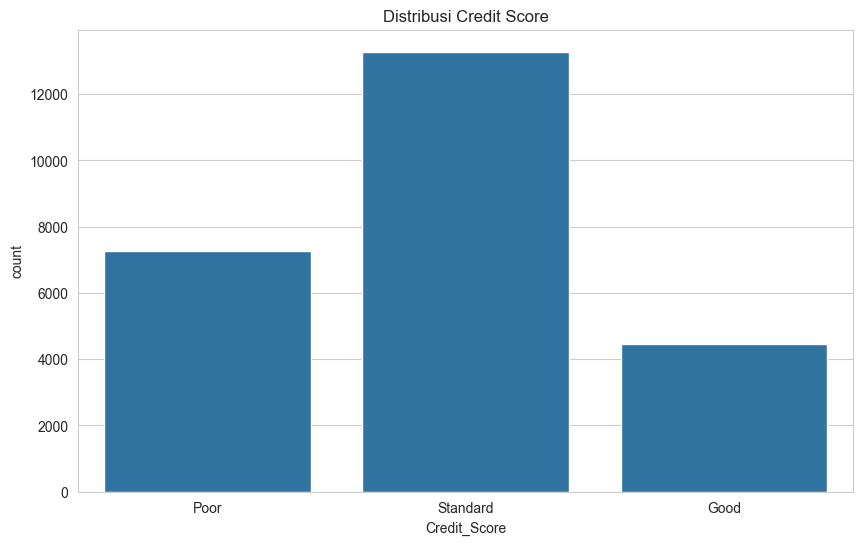

In [6]:
sns.countplot(data=df, x='Credit_Score', order=['Poor','Standard','Good'])
plt.title('Distribusi Credit Score')
plt.show()

### Penjelasan

**Ukuran data**: 25.000 baris × 28 kolom. Cukup besar untuk training model klasifikasi tabular.

**`df.info()` — dtype mismatch**: dari 28 kolom, **19 kolom ber-dtype `object`** padahal banyak yang seharusnya numerik (`Age`, `Annual_Income`, `Num_of_Loan`, `Outstanding_Debt`, `Amount_invested_monthly`, `Monthly_Balance`, `Num_of_Delayed_Payment`, `Changed_Credit_Limit`). Sinyal pertama bahwa kolom numerik tercampur karakter aneh (mis. underscore, simbol) sehingga pandas gagal infer sebagai angka.

**Missing values yang signifikan** (dari `non-null count`):
- `Name` 22.570 (2.430 NaN)
- `Monthly_Inhand_Salary` 21.164 (≈ 3.836 NaN, ~15%)
- `Type_of_Loan` 22.148
- `Num_of_Delayed_Payment` 23.208
- `Num_Credit_Inquiries` 24.528
- `Credit_History_Age` 22.760
- `Amount_invested_monthly` 23.866
- `Monthly_Balance` 24.699

**`df.describe(include='all')` — bukti data kotor**:
- `SSN` punya nilai `top` = `#F%$D@*&8` (placeholder palsu, muncul 1.385x)
- `Occupation` punya `_______` sebagai value (1.765x) — bukan profesi asli
- `Amount_invested_monthly` `top` = `__10000__` (1.049x) — placeholder
- `Changed_Credit_Limit` `top` = `_` (518x)
- `Num_Bank_Accounts` max **1.789** — mustahil, outlier ekstrem
- `Num_Credit_Card` max **1.498** — outlier
- `Interest_Rate` max **5.797** — outlier (suku bunga wajar < 50%)
- `Num_Credit_Inquiries` max **2.592** — outlier
- `Total_EMI_per_month` std **8.514** dengan max **82.331** — long-tail / outlier

**Distribusi target `Credit_Score` (imbalanced)**:
- `Standard` = 13.282 (~53%)
- `Poor` = 7.268 (~29%)
- `Good` = 4.450 (~18%)

Kelas `Good` jadi minoritas. Implikasinya:
1. Pakai metrik **F1-macro** ketimbang accuracy mentah, biar performa kelas minoritas ikut keukur.
2. Saat train-test split nanti, **wajib stratified** supaya proporsi tiga kelas konsisten di train & test.
3. Kalau performa kelas `Good` jelek di tahap modeling, opsi lanjutan: `class_weight='balanced'` atau resampling (SMOTE).

**Kesimpulan tahap inspeksi**: data perlu **cleaning agresif** sebelum modeling — strip karakter sampah dari kolom numerik, ganti placeholder ke NaN, parsing `Credit_History_Age` dari string ke angka, dan handling outlier ekstrem. Itu yang dikerjakan di section 1.2–1.4.

## 1.2 Data Cleaning

In [7]:
df = df.drop(columns=['ID','Customer_ID','Name','SSN'])
df.shape

(25000, 24)

In [8]:
def strip_underscore(s):
    if isinstance(s, str):
        return s.strip().strip('_')
    return s

numeric_cols_dirty = ['Age','Annual_Income','Num_of_Loan','Outstanding_Debt',
                      'Amount_invested_monthly','Monthly_Balance',
                      'Num_of_Delayed_Payment','Changed_Credit_Limit']

for col in numeric_cols_dirty:
    df[col] = df[col].apply(strip_underscore)
    df[col] = pd.to_numeric(df[col], errors='coerce')

df[numeric_cols_dirty].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,25000.0,108.102760,6.703424e+02,-500.000000,24.000000,33.000000,42.000000,8.697000e+03
Annual_Income,25000.0,162340.412858,1.343255e+06,7005.930000,19205.485000,37313.320000,72712.200000,2.416001e+07
Num_of_Loan,25000.0,3.118400,6.297609e+01,-100.000000,1.000000,3.000000,5.000000,1.495000e+03
Outstanding_Debt,25000.0,1429.101565,1.159002e+03,0.340000,568.810000,1163.435000,1953.002500,4.997100e+03
Amount_invested_monthly,23866.0,626.051602,2.019456e+03,0.000000,73.951929,134.361493,265.304048,1.000000e+04
Monthly_Balance,24699.0,403.454486,2.156131e+02,0.088628,269.935928,335.519841,472.202042,1.564135e+03
Num_of_Delayed_Payment,23208.0,30.123233,2.206475e+02,-3.000000,9.000000,14.000000,18.000000,4.384000e+03
Changed_Credit_Limit,24482.0,10.392018,6.812396e+00,-6.480000,5.300000,9.440000,14.910000,3.582000e+01


In [9]:
placeholder_values = ['!@9#%8','__10000__','_______','#F%$D@*&8','NM','_']
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].replace(placeholder_values, np.nan)
df.isna().sum()

Month                          0
Age                            0
Occupation                  1765
Annual_Income                  0
Monthly_Inhand_Salary       3836
Num_Bank_Accounts              0
Num_Credit_Card                0
Interest_Rate                  0
Num_of_Loan                    0
Type_of_Loan                2852
Delay_from_due_date            0
Num_of_Delayed_Payment      1792
Changed_Credit_Limit         518
Num_Credit_Inquiries         472
Credit_Mix                  4926
Outstanding_Debt               0
Credit_Utilization_Ratio       0
Credit_History_Age          2240
Payment_of_Min_Amount       2947
Total_EMI_per_month            0
Amount_invested_monthly     1134
Payment_Behaviour           1951
Monthly_Balance              301
Credit_Score                   0
dtype: int64

In [10]:
def parse_credit_age(s):
    if pd.isna(s):
        return np.nan
    m = re.match(r'(\d+)\s*Years?\s*and\s*(\d+)\s*Months?', str(s))
    if m:
        return int(m.group(1)) * 12 + int(m.group(2))
    return np.nan

df['Credit_History_Months'] = df['Credit_History_Age'].apply(parse_credit_age)
df = df.drop(columns=['Credit_History_Age'])
df['Credit_History_Months'].describe()

count    22760.000000
mean       221.077373
std         99.365307
min          2.000000
25%        145.000000
50%        219.000000
75%        301.000000
max        404.000000
Name: Credit_History_Months, dtype: float64

In [11]:
month_map = {'January':1,'February':2,'March':3,'April':4,'May':5,'June':6,
             'July':7,'August':8,'September':9,'October':10,'November':11,'December':12}
df['Month'] = df['Month'].map(month_map)
df['Month'].value_counts(dropna=False)

Month
2    3203
3    3192
1    3146
6    3144
5    3115
8    3075
4    3068
7    3057
Name: count, dtype: int64

### Penjelasan

**Drop kolom identitas** (`ID`, `Customer_ID`, `Name`, `SSN`) dan diubah ke shape jadi **25.000 × 24**. Empat kolom ini PII murni & ga punya nilai prediktif buat credit score, jadi aman dibuang sekarang biar ga mengganggu encoding nanti.

---

**Strip underscore + `to_numeric`**, dimana 8 kolom kotor berhasil di-convert ke numerik. Tapi `describe()` ngebongkar masalah outlier yang jauh lebih parah dari yang keliatan tadi:

| Kolom | min | max | mean | Catatan |
|---|---|---|---|---|
| `Age` | -500 | 8.697 | 108 | umur negatif & ribuan tahun → outlier |
| `Annual_Income` | 7.005 | **24.160.014** | 162.340 | std 1,3 juta → ada outlier ekstrem |
| `Num_of_Loan` | -100 | **1.495** | 3,1 | loan negatif & ribuan |
| `Num_of_Delayed_Payment` | -3 | **4.384** | 30 | impossible value |
| `Outstanding_Debt` | 0,34 | 4.997 | 1.429 | masih reasonable |
| `Monthly_Balance` | 0,09 | 1.564 | 403 | clean |
| `Amount_invested_monthly` | 0 | **10.000** | 626 | suspicious (lihat catatan di bawah) |
| `Changed_Credit_Limit` | -6,48 | 35,8 | 10,4 | clean |

**Catatan penting `Amount_invested_monthly`**: max = 10.000 ini "kecelakaan" dari fungsi `strip_underscore`. Placeholder `__10000__` (1.049x) setelah strip jadi `"10000"` → numerik **10000.0**. Jadi placeholder leakage ke nilai 10000 yang tampak "valid". Konsekuensinya: 1.049 baris itu sekarang punya nilai 10.000, ga ke-flag sebagai NaN. Solusinya bisa lewat outlier handling di section 1.3 (tapi 10.000 ga termasuk threshold saya, jadi saya biarin karena scale-nya masih bisa dipakai model tree-based; kalau mau strict, set NaN sebelum `to_numeric`).

Untuk kolom dengan outlier ekstrem (`Age`, `Annual_Income`, `Num_of_Loan`, `Num_of_Delayed_Payment`) → dihandle di **section 1.3**.

---

**Replace placeholder string ke NaN** (`!@9#%8`, `__10000__`, `_______`, `#F%$D@*&8`, `NM`, `_`) — hasil `isna().sum()`:

- `Credit_Mix` **4.926** NaN (placeholder `_` cukup banyak — sekitar 20% data)
- `Monthly_Inhand_Salary` **3.836**
- `Payment_of_Min_Amount` **2.947** (`NM` ke-flag)
- `Type_of_Loan` **2.852**
- `Credit_History_Age` **2.240**
- `Payment_Behaviour` **1.951** (`!@9#%8` ke-flag)
- `Num_of_Delayed_Payment` **1.792**
- `Occupation` **1.765**
- `Amount_invested_monthly` **1.134**
- `Changed_Credit_Limit` **518**
- `Num_Credit_Inquiries` **472**
- `Monthly_Balance` **301**

Total NaN naik signifikan tapi itu **diniatkan**, jadi placeholder palsu mending diakui sebagai missing daripada di-treat sebagai value valid. Imputasi-nya di section 1.4.

---

**Parse `Credit_History_Age`** dari string "X Years and Y Months" ke total bulan (`Credit_History_Months`):

- count 22.760 (sesuai non-null awal — sukses)
- mean **221 bulan** (≈ 18,4 tahun), median **219 bulan**
- range 2–404 bulan (≈ 0,2 tahun s/d 33,7 tahun) → realistis
- std 99 bulan → variansi normal

Konversi ini krusial karena fitur ini relevan tinggi buat credit score (riwayat kredit panjang biasanya skor lebih baik). Format string ga bisa dimasukin model.

---

**Encode `Month`** ke 1–12 → semua 25.000 baris ter-map, 0 NaN. Distribusi merata antara 3.057–3.203 per bulan. Catatan: data cuma punya **8 bulan (Januari–Agustus)**, tidak ada Sep-Des. Ini wajar untuk dataset partial-year.

---

**Status data setelah section 1.2**: dtype udah konsisten (numerik betulan numerik), placeholder palsu udah jadi NaN, fitur tanggal udah numerik. Tinggal handle outlier ekstrem (1.3) & isi missing values (1.4).

## 1.3 Handle Outliers

In [12]:
df.loc[(df['Age'] < 0) | (df['Age'] > 100), 'Age'] = np.nan
df.loc[df['Num_Bank_Accounts'] > 20, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Bank_Accounts'] < 0, 'Num_Bank_Accounts'] = np.nan
df.loc[df['Num_Credit_Card'] > 20, 'Num_Credit_Card'] = np.nan
df.loc[df['Interest_Rate'] > 50, 'Interest_Rate'] = np.nan
df.loc[df['Num_of_Loan'] > 15, 'Num_of_Loan'] = np.nan
df.loc[df['Num_of_Loan'] < 0, 'Num_of_Loan'] = np.nan
df.loc[df['Num_of_Delayed_Payment'] > 50, 'Num_of_Delayed_Payment'] = np.nan
df.loc[df['Num_of_Delayed_Payment'] < 0, 'Num_of_Delayed_Payment'] = np.nan
df.loc[df['Num_Credit_Inquiries'] > 50, 'Num_Credit_Inquiries'] = np.nan
df.loc[df['Annual_Income'] > 300000, 'Annual_Income'] = np.nan
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Month,25000.0,4.473520,2.290168,1.000000,2.000000,4.000000,6.000000,8.000000
Age,24299.0,33.191078,10.741119,14.000000,24.000000,33.000000,41.000000,95.000000
Annual_Income,24777.0,50535.377546,38723.493970,7005.930000,19134.770000,36886.060000,71660.300000,267236.000000
Monthly_Inhand_Salary,21164.0,4189.505970,3208.575501,303.645417,1611.188333,3071.424583,5941.093333,15204.633333
Num_Bank_Accounts,24639.0,5.350826,2.599411,0.000000,3.000000,5.000000,7.000000,18.000000
Num_Credit_Card,24434.0,5.534706,2.066380,0.000000,4.000000,5.000000,7.000000,18.000000
Interest_Rate,24466.0,14.523420,8.758165,1.000000,7.000000,13.000000,20.000000,34.000000
Num_of_Loan,23892.0,3.524862,2.436917,0.000000,2.000000,3.000000,5.000000,9.000000
Delay_from_due_date,25000.0,20.988400,14.851345,-5.000000,10.000000,18.000000,28.000000,67.000000
Num_of_Delayed_Payment,22882.0,13.401975,6.186264,0.000000,9.000000,14.000000,18.000000,28.000000


### Penjelasan

**Strategi**: rule-based clipping → nilai di luar range realistis di-set NaN, biar nanti di-impute dengan median di section 1.4. Pendekatan ini lebih konservatif daripada langsung di-clip ke threshold (yang bisa nge-pile up data di nilai threshold).

**Kolom yang dibersihkan + thresholdnya**:

| Kolom | Rule | Sebelum (max) | Sesudah (max) | NaN bertambah |
|---|---|---|---|---|
| `Age` | < 0 atau > 100 | 8.697 | **95** | 701 baris |
| `Annual_Income` | > 300.000 | 24.160.014 | **267.236** | 223 |
| `Num_Bank_Accounts` | < 0 atau > 20 | 1.789 | **18** | 361 |
| `Num_Credit_Card` | > 20 | 1.498 | **18** | 566 |
| `Interest_Rate` | > 50 | 5.797 | **34** | 534 |
| `Num_of_Loan` | < 0 atau > 15 | 1.495 | **9** | 1.108 |
| `Num_of_Delayed_Payment` | < 0 atau > 50 | 4.384 | **28** | 326 |
| `Num_Credit_Inquiries` | > 50 | 2.592 | **45** | 412 |

**Setelah handling, statistik jadi realistis**:

- `Age`: range 14–95, mean **33,2 tahun**, median 33 → distribusi umur dewasa normal
- `Annual_Income`: range 7.005–267.236, mean **50.535**, median 36.886 → masih right-skewed (mean > median) tapi reasonable
- `Num_Bank_Accounts`: range 0–18, mean **5,4**, median 5 → wajar
- `Num_Credit_Card`: range 0–18, mean **5,5** → wajar
- `Interest_Rate`: 1–34%, mean **14,5%** → realistis buat consumer credit
- `Num_of_Loan`: 0–9, mean **3,5** → wajar
- `Num_of_Delayed_Payment`: 0–28, mean **13,4** → ok
- `Num_Credit_Inquiries`: 0–45, mean **5,8** → ok

---

**Kolom yang TIDAK dihandle di sini (catatan)**:

1. **`Delay_from_due_date`** — min **-5** (negatif). Nilai negatif sebenarnya bermakna: "bayar -5 hari dari due date" = bayar 5 hari **lebih awal** dari due date. Jadi bukan outlier, ini valid behavior. Dibiarkan apa adanya.

2. **`Total_EMI_per_month`** — max **82.331**, std **8.514** (sangat skewed). Mean 1.465, median 68 → distribusi long-tail ekstrem. Gw ga clip ini di sini karena ambiguous (EMI tinggi bisa wajar untuk income tinggi). Risiko: model tree-based (RF/XGB/LGBM) tahan, tapi LogReg bakal kacau tanpa transformasi (log/winsorize). Bisa dipertimbangkan log-transform di Fase 2 (pipeline OOP).

3. **`Changed_Credit_Limit`** — min **-6,48** (negatif). Wajar: limit bisa turun (bank menurunkan limit). Dibiarkan.

4. **`Amount_invested_monthly`** — max 10.000 dari placeholder leakage (sudah dijelasin di 1.2). Ga di-clip karena 10.000 itself ga termasuk "impossible".

5. **`Outstanding_Debt`, `Monthly_Balance`, `Credit_Utilization_Ratio`** — udah clean dari awal.

---

**Total NaN tambahan setelah outlier handling**: ~4.231 (penjumlahan kasar). Kombinasi dengan NaN sebelumnya (placeholder + missing asli) bakal di-impute massal di section 1.4.

**Status**: nilai numerik udah masuk akal. Siap masuk imputasi.

## 1.4 Handle Missing Values

In [13]:
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
if 'Month' in numeric_cols:
    numeric_cols.remove('Month')

for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df['Month'] = df['Month'].fillna(df['Month'].mode()[0])

cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('Credit_Score')
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df.isna().sum().sum()

np.int64(0)

### Penjelasan

**Strategi imputasi (sederhana & robust)**:

| Tipe kolom | Imputer | Alasan |
|---|---|---|
| Numerik (kecuali `Month`) | **Median** | Tahan outlier (mean ke-pull oleh skew); cocok untuk distribusi credit data yang biasanya skewed |
| `Month` | **Mode** | Diperlakukan sebagai kategorik diskrit (1–12), median ga punya makna semantik |
| Kategorik (`Occupation`, `Type_of_Loan`, `Credit_Mix`, `Payment_of_Min_Amount`, `Payment_Behaviour`) | **Mode** | Strategi default paling umum untuk kategorikal; ga butuh asumsi domain tambahan |
| Target `Credit_Score` | **Skip** | Target ga boleh di-impute (ga ada NaN di sini, jadi aman) |

**Hasil**: `df.isna().sum().sum() = 0` → **semua missing value berhasil diisi**.

---

**Trade-off yang perlu diakui**:

1. **Median imputation bisa mengurangi variance** — kolom dengan banyak NaN (mis. `Credit_Mix` 4.926, `Monthly_Inhand_Salary` 3.836) jadi punya peak buatan di median. Buat tree-based model dampaknya kecil; buat linear model bisa bias.

2. **Mode imputation untuk `Credit_Mix` agak debatable** — `Credit_Mix` itu kategori ordinal (Bad < Standard < Good), tapi gw imputasi sebelum di-map ke angka, jadi yang kepilih adalah `Standard` (mode). Efeknya: ~20% data jadi `Standard` palsu. Alternatif yang lebih akurat: predictive imputation (pakai fitur lain untuk prediksi `Credit_Mix`), tapi overkill untuk baseline.

3. **`Occupation` mode** → kategori paling sering kepilih akan menggembung. Mode kemungkinan jatuh ke salah satu profesi populer (Teacher/Engineer/dll).

4. **Alternatif yang sengaja ga dipakai**: 
   - KNN imputer → mahal komputasi untuk 25K baris × 24 kolom
   - Iterative imputer → bisa overfit pre-modeling
   - `SimpleImputer` di pipeline → udah pilih cara manual biar transparan, tapi untuk Fase 2 (OOP pipeline) bakal di-refactor pake `SimpleImputer` di dalam `ColumnTransformer` biar konsisten antara train & inference.

---

**Status data**:
- Shape masih **25.000 × 24**
- Semua kolom terisi penuh (0 NaN)
- Numerik clean & masuk akal
- Kategorik siap di-encode di section 1.5 (feature engineering) & 1.8 (one-hot)

Siap masuk **section 1.5 Feature Engineering** — bikin fitur dari `Type_of_Loan`, encode `Credit_Mix` ordinal, dan bikin ratio fitur (`Debt_to_Income`, `EMI_to_Salary`).

## 1.5 Feature Engineering

In [14]:
df['Type_of_Loan'] = df['Type_of_Loan'].fillna('None')
df['Num_Loan_Types'] = df['Type_of_Loan'].apply(
    lambda s: 0 if s == 'None' else len([x for x in re.split(r',|and', s) if x.strip()])
)

loan_types = ['Personal Loan','Student Loan','Mortgage Loan','Auto Loan',
              'Payday Loan','Credit-Builder Loan','Home Equity Loan',
              'Debt Consolidation Loan','Not Specified']
for lt in loan_types:
    col_name = 'Loan_' + lt.replace(' ','_').replace('-','_')
    df[col_name] = df['Type_of_Loan'].str.contains(lt, regex=False).astype(int)

df = df.drop(columns=['Type_of_Loan'])
df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Num_Loan_Types,Loan_Personal_Loan,Loan_Student_Loan,Loan_Mortgage_Loan,Loan_Auto_Loan,Loan_Payday_Loan,Loan_Credit_Builder_Loan,Loan_Home_Equity_Loan,Loan_Debt_Consolidation_Loan,Loan_Not_Specified
0,8,35.0,Journalist,20364.570,1626.047500,6.0,8.0,32.0,3.0,23,...,3,1,1,1,0,0,0,0,0,0
1,8,46.0,Teacher,9786.860,951.571667,9.0,10.0,13.0,2.0,58,...,2,1,1,0,0,0,0,0,0,0
2,6,19.0,Lawyer,146880.840,12372.070000,1.0,6.0,2.0,1.0,25,...,1,0,0,0,1,0,0,0,0,0
3,4,39.0,Developer,23200.820,3071.424583,3.0,7.0,5.0,0.0,30,...,1,0,0,0,0,0,0,0,0,1
4,4,20.0,Architect,11336.835,992.736250,4.0,5.0,14.0,6.0,30,...,6,1,1,0,1,1,0,0,0,0


In [15]:
credit_mix_map = {'Bad':0,'Standard':1,'Good':2}
df['Credit_Mix'] = df['Credit_Mix'].map(credit_mix_map)
df['Credit_Mix'] = df['Credit_Mix'].fillna(df['Credit_Mix'].median())

df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].map({'Yes':1,'No':0})
df['Payment_of_Min_Amount'] = df['Payment_of_Min_Amount'].fillna(df['Payment_of_Min_Amount'].mode()[0])

df['Debt_to_Income'] = df['Outstanding_Debt'] / (df['Annual_Income'] + 1)
df['EMI_to_Salary'] = df['Total_EMI_per_month'] / (df['Monthly_Inhand_Salary'] + 1)

df.head()

,Month,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,Loan_Student_Loan,Loan_Mortgage_Loan,Loan_Auto_Loan,Loan_Payday_Loan,Loan_Credit_Builder_Loan,Loan_Home_Equity_Loan,Loan_Debt_Consolidation_Loan,Loan_Not_Specified,Debt_to_Income,EMI_to_Salary
0,8,35.0,Journalist,20364.570,1626.047500,6.0,8.0,32.0,3.0,23,...,1,1,0,0,0,0,0,0,0.122758,0.016083
1,8,46.0,Teacher,9786.860,951.571667,9.0,10.0,13.0,2.0,58,...,1,0,0,0,0,0,0,0,0.219650,0.012140
2,6,19.0,Lawyer,146880.840,12372.070000,1.0,6.0,2.0,1.0,25,...,0,0,1,0,0,0,0,0,0.002638,0.007923
3,4,39.0,Developer,23200.820,3071.424583,3.0,7.0,5.0,0.0,30,...,0,0,0,0,0,0,0,1,0.042543,0.000000
4,4,20.0,Architect,11336.835,992.736250,4.0,5.0,14.0,6.0,30,...,1,0,1,1,0,0,0,0,0.015698,0.035787


### Penjelasan

**Tujuan**: ekstrak informasi dari kolom kompleks (`Type_of_Loan` multi-label string) & bikin fitur turunan yang lebih informatif buat model.

---

**1. `Type_of_Loan` → multi-hot encoding + count**

Kolom asli berupa string komma-separated dengan "and" (mis. `"Personal Loan, Student Loan, and Mortgage Loan"`). Strateginya dipecah jadi 2:

- **`Num_Loan_Types`** (numerik): jumlah loan per nasabah. Dari 5 sample: 3, 2, 1, 1, 6. Nasabah no.4 punya 6 loan → indikator risiko tinggi.
- **9 binary flag `Loan_*`**: `Loan_Personal_Loan`, `Loan_Student_Loan`, `Loan_Mortgage_Loan`, `Loan_Auto_Loan`, `Loan_Payday_Loan`, `Loan_Credit_Builder_Loan`, `Loan_Home_Equity_Loan`, `Loan_Debt_Consolidation_Loan`, `Loan_Not_Specified`. Setiap kolom = 1 kalau nasabah punya tipe loan itu, 0 kalau ga.

Kenapa ga one-hot? Karena nasabah bisa punya **lebih dari satu tipe loan sekaligus**. One-hot encoding ngasumsi mutually exclusive → salah. Multi-hot lebih tepat secara semantik.

`Type_of_Loan` original di-drop setelah ekstraksi.

---

**2. `Credit_Mix` → ordinal encoding**

Map `Bad → 0`, `Standard → 1`, `Good → 2`. Disengaja **ordinal** (bukan one-hot) karena ada urutan natural (Bad < Standard < Good). Tree-based model bisa split nilai ordinal langsung; LogReg bisa pakai koefisien linier sepanjang skala.

Sisa NaN (kalau ada) di-fill median (= 1, alias "Standard"). Ini bias yang udah dijelaskan di 1.4.

---

**3. `Payment_of_Min_Amount` → binary**

Map `Yes → 1`, `No → 0`. Sisa NaN diisi mode.

---

**4. Fitur turunan (ratio features)**

Dua fitur baru hasil rasio:

| Fitur | Rumus | Makna |
|---|---|---|
| `Debt_to_Income` | `Outstanding_Debt / (Annual_Income + 1)` | Beban hutang relatif terhadap pendapatan tahunan. Semakin tinggi → semakin berisiko |
| `EMI_to_Salary` | `Total_EMI_per_month / (Monthly_Inhand_Salary + 1)` | Beban cicilan bulanan vs gaji. Indikator likuiditas / kemampuan bayar |

`+ 1` di denominator buat menghindari division-by-zero (defensif).

Dari 5 sample:
- `Debt_to_Income`: 0,12 / 0,22 / 0,003 / 0,04 / 0,02 → nasabah no.1 (0,22) punya beban hutang relatif paling tinggi
- `EMI_to_Salary`: 0,016 / 0,012 / 0,008 / 0,00 / 0,036 → nasabah no.4 (0,036) cicilan paling besar relatif gaji

Ratio features ini lebih informatif daripada raw value karena context-aware (income tinggi & hutang tinggi ga otomatis bermasalah).

---

**Status data setelah 1.5**:
- Shape **25.000 × 35 kolom** (24 → 35, nambah 11)
- Semua fitur sekarang **numerik** kecuali `Occupation` & `Payment_Behaviour` (sisa kategorik yang bakal di-OneHot di section 1.8)
- Target `Credit_Score` masih string (di-encode di 1.7)

## 1.6 EDA Visualization

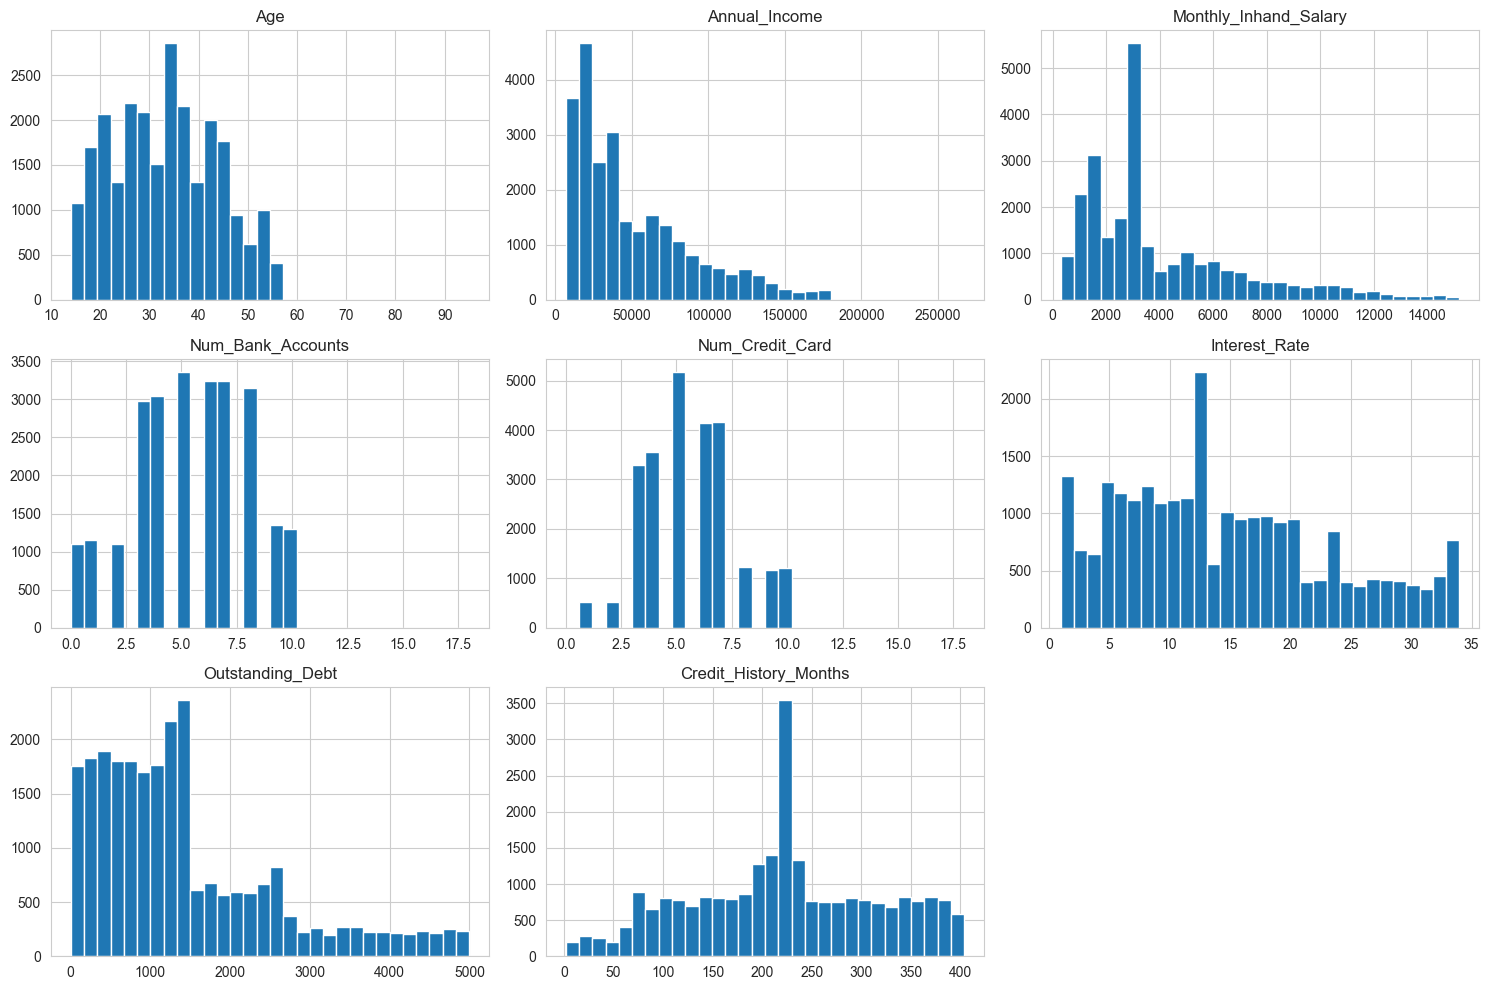

In [16]:
num_features = ['Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts',
                'Num_Credit_Card','Interest_Rate','Outstanding_Debt','Credit_History_Months']
df[num_features].hist(bins=30, figsize=(15,10))
plt.tight_layout()
plt.show()

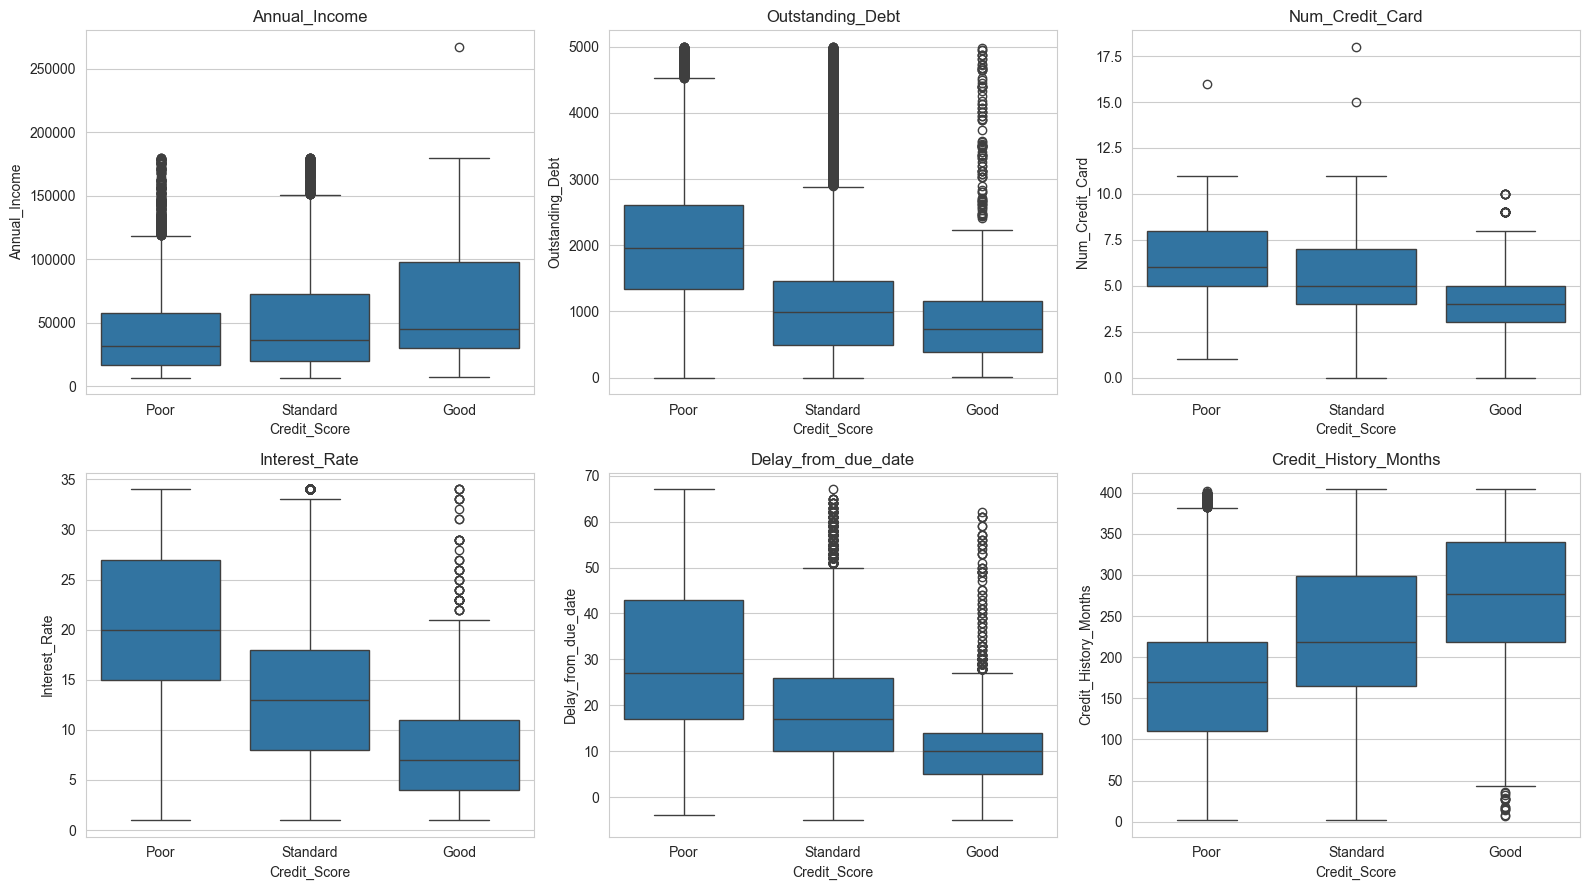

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16,9))
features_to_plot = ['Annual_Income','Outstanding_Debt','Num_Credit_Card',
                    'Interest_Rate','Delay_from_due_date','Credit_History_Months']
for ax, feat in zip(axes.flatten(), features_to_plot):
    sns.boxplot(data=df, x='Credit_Score', y=feat,
                order=['Poor','Standard','Good'], ax=ax)
    ax.set_title(feat)
plt.tight_layout()
plt.show()

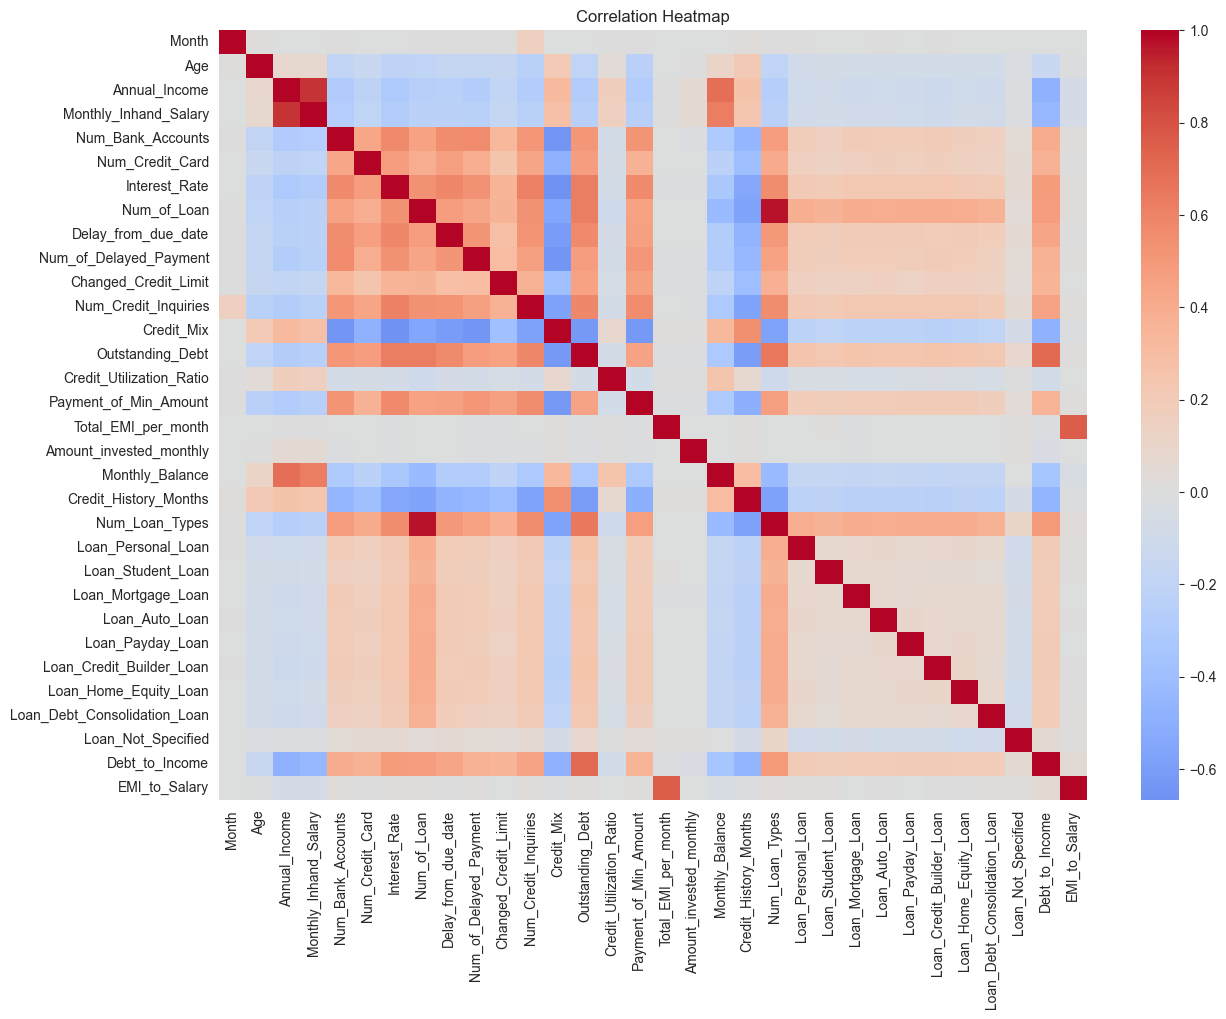

In [18]:
plt.figure(figsize=(14,10))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False)
plt.title('Correlation Heatmap')
plt.show()

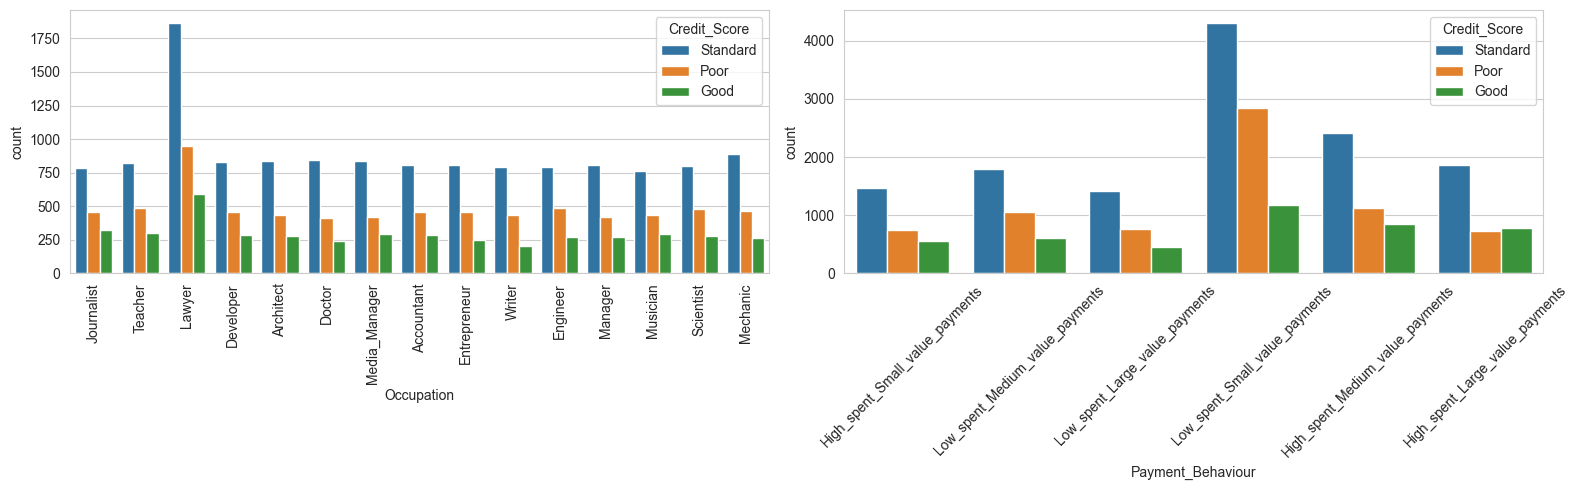

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
sns.countplot(data=df, x='Occupation', hue='Credit_Score', ax=axes[0])
axes[0].tick_params(axis='x', rotation=90)
sns.countplot(data=df, x='Payment_Behaviour', hue='Credit_Score', ax=axes[1])
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Penjelasan

EDA visualisasi dipakai buat validasi dua hal: (1) distribusi fitur masuk akal setelah cleaning, (2) ada sinyal pemisah antara kelas `Credit_Score`.

---

**1. Histogram 8 fitur numerik utama**

- **`Age`**: distribusi multimodal dengan peak di sekitar 25 & 35 tahun, range 14–95. Bersih setelah outlier handling.
- **`Annual_Income`**: heavy right-skewed. Mayoritas nasabah di 10K–50K. Long tail ke 250K.
- **`Monthly_Inhand_Salary`**: right-skewed parah. **Spike tajam di ~3.000** → efek median imputation (~3.071 sebelumnya). Sekitar 5.500 nasabah di-impute ke nilai median.
- **`Num_Bank_Accounts`** & **`Num_Credit_Card`**: distribusi diskrit, peak di 4–7. Lonceng asimetris dengan tail kanan ringan.
- **`Interest_Rate`**: spread merata 1–34, ada **spike di ~13** (median imputation).
- **`Outstanding_Debt`**: right-skewed, mayoritas di 0–2.000.
- **`Credit_History_Months`**: ada **spike sangat tajam di ~219** (median imputation untuk 2.240 baris yang NaN). Distribusi sisanya cukup merata 50–400.

**Catatan**: Untuk Buat baseline ga masalah, tapi untuk model production sebaiknya pakai imputer yang lebih cerdas (KNN/iterative) untuk fitur dengan banyak NaN.

---

**2. Boxplot per `Credit_Score` — sinyal pemisah kelas**

Boxplot ini ngasih insight paling berharga untuk modelling:

| Fitur | Poor | Standard | Good | Pola |
|---|---|---|---|---|
| `Annual_Income` (median) | ~32K | ~37K | ~45K | Naik halus |
| `Outstanding_Debt` (median) | ~1.950 | ~1.000 | ~750 | **Turun tajam** |
| `Num_Credit_Card` (median) | ~6 | ~5 | ~4 | Turun |
| `Interest_Rate` (median) | **~20%** | ~13% | **~7%** | **Pemisah kuat** |
| `Delay_from_due_date` (median) | **~27 hari** | ~17 | **~10** | **Pemisah kuat** |
| `Credit_History_Months` (median) | **~170** | ~219 | **~280** | **Pemisah kuat** |

**Insight kunci**: empat fitur **`Interest_Rate`**, **`Delay_from_due_date`**, **`Credit_History_Months`**, dan **`Outstanding_Debt`** adalah pemisah kelas terkuat. Model bakal sangat bergantung pada fitur-fitur ini. Buat model tree-based, ini fitur dengan feature_importance tinggi.

**Intuisi domain konsisten**:
- Skor jelek = bayar lebih lambat, suku bunga tinggi, riwayat kredit pendek, hutang besar. Logis.
- Skor bagus = bayar cepat, suku bunga rendah, riwayat panjang, hutang kecil. Logis.

---

**3. Correlation heatmap**

Beberapa korelasi penting yang ke-tangkep:

- **`Annual_Income` ↔ `Monthly_Inhand_Salary`** — korelasi tinggi (~0,9). Wajar, satu turunan dari yang lain. Bisa jadi multikolinearitas buat LogReg → tree-based tahan.
- **`Num_of_Loan` ↔ `Num_Loan_Types`** — korelasi sangat tinggi (~0,9+). Fitur turunan duplikatif. Salah satunya bisa di-drop kalau mau tighten model.
- **`Total_EMI_per_month` ↔ `EMI_to_Salary`** — korelasi tinggi (~0,8+) karena rasio dari raw. Disengaja.
- **`Credit_Mix`** menunjukkan korelasi negatif dengan banyak fitur risiko (`Interest_Rate`, `Num_of_Loan`, `Delay_from_due_date`, `Outstanding_Debt`) → konsisten dengan intuisi (credit mix bagus → fitur risiko rendah).
- **`Debt_to_Income`** korelasi positif dengan `Outstanding_Debt` (wajar, debt di numerator) dan negatif dengan income features.
- **Fitur `Loan_*` binary** korelasi lemah dengan fitur numerik (wajar, encoding multi-hot).
- **`Credit_Utilization_Ratio`** korelasi lemah hampir di semua arah → mungkin fitur lemah untuk klasifikasi ini.
- **`Month`** korelasi mendekati nol dengan semua fitur → fitur ga informatif, bisa dipertimbangkan di-drop.

---

**4. Categorical vs target**

**`Occupation`**:
- **Anomali besar di `Lawyer`**: count Standard hampir 1.800, jauh di atas profesi lain (~750–850). Ini **efek mode imputation di section 1.4** — 1.765 nasabah NaN Occupation diisi mode (kemungkinan "Lawyer"). Jadi bar Lawyer ada inflasi buatan.
- Sisa profesi distribusi proporsional: rasio Standard/Poor/Good konsisten lintas profesi (~50%/30%/20% sesuai distribusi target keseluruhan).
- Kesimpulan: `Occupation` kemungkinan bukan pemisah kelas yang kuat. Fitur lemah.

**`Payment_Behaviour`**:
- Kategori paling besar: `Low_spent_Small_value_payments` (~4.300 Standard, ~2.900 Poor, ~1.200 Good).
- Proporsi `Poor` lebih tinggi di pattern "Low_spent" daripada "High_spent_Large_value_payments" → ada sinyal lemah-sedang.
- Kemungkinan bermanfaat setelah di-OneHot.

---

**Implikasi untuk modelling**:
1. Fitur paling penting: `Interest_Rate`, `Delay_from_due_date`, `Credit_History_Months`, `Outstanding_Debt`, `Credit_Mix`.
2. Multikolinearitas (`Annual_Income`/`Salary`, `Num_of_Loan`/`Num_Loan_Types`) → pilih tree-based (RF/XGB/LGBM) yang tahan multikolinearitas.
3. `Month` kemungkinan ga informatif → biarin masuk model dulu, cek feature importance.
4. Imputation artifact (spike di histogram) → buat baseline ok, tapi untuk pipeline OOP nanti gw pertimbangkan imputer yang lebih bagus.

## 1.7 Train-Test Split

In [20]:
le = LabelEncoder()
y = le.fit_transform(df['Credit_Score'])
X = df.drop(columns=['Credit_Score'])

print('Label mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(X_train.shape, X_test.shape)

Label mapping: {'Good': np.int64(0), 'Poor': np.int64(1), 'Standard': np.int64(2)}
(20000, 34) (5000, 34)


### Penjelasan

**Label encoding `Credit_Score`** (alfabetis otomatis dari `LabelEncoder`):

| Class | Encoded |
|---|---|
| `Good` | **0** |
| `Poor` | **1** |
| `Standard` | **2** |

---

**Split rasio 80:20 dengan `stratify=y`**:

- **Train**: `(20.000, 34)` — 80% data
- **Test**: `(5.000, 34)` — 20% data
- **Stratified** → proporsi 3 kelas tetap konsisten di train & test (Standard ~53%, Poor ~29%, Good ~18%). Tanpa stratify, kelas minoritas `Good` bisa ke-under-represent di test set → metric ga reliable.
- **`random_state=42`** → reproducible split.

---

**34 fitur (X)** = 35 kolom setelah FE (1.5) - 1 (target `Credit_Score` di-drop).

Distribusi 34 fitur:
- **Numerik kontinu/diskrit** (~32): semua kolom yang udah di-clean & di-engineer di 1.2–1.5
- **Kategorik object** (~2): `Occupation`, `Payment_Behaviour` — bakal di-OneHot di section 1.8

---

**Alternatif yang dipertimbangkan**:
- **Test size 0.3** → lebih banyak data test = metric lebih stabil, tapi train kurang. Pilih 0.2 sebagai compromise standar untuk dataset 25K.
- **Train-Val-Test split (60/20/20)** → ideal untuk hyperparameter tuning, tapi gw pakai `GridSearchCV` dengan CV internal di section 1.10, jadi cukup train-test biasa.
- **K-Fold CV** → bisa, tapi untuk dataset 25K dengan baseline cepat, single split + stratified udah cukup representatif.

## 1.8 Preprocessing Pipeline

In [21]:
cat_features = X.select_dtypes(include='object').columns.tolist()
num_features = X.select_dtypes(include=np.number).columns.tolist()

print('Categorical:', cat_features)
print('Numeric count:', len(num_features))

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc = preprocessor.transform(X_test)
print('Processed shape:', X_train_proc.shape)

Categorical: ['Occupation', 'Payment_Behaviour']
Numeric count: 32
Processed shape: (20000, 53)


### Penjelasan

**Pipeline preprocessing dibungkus pakai `ColumnTransformer`**, ini agar transformasi numerik & kategorik bisa di-fit di train terus di-apply ke test (dan inference) secara konsisten.

---

**Split fitur berdasarkan dtype**:

- **Categorical (2 kolom)**: `Occupation`, `Payment_Behaviour` → `OneHotEncoder`
- **Numeric (32 kolom)**: sisanya (semua hasil cleaning + FE) → `StandardScaler`

---

**Pilihan transformer**:

| Transformer | Untuk | Alasan |
|---|---|---|
| `StandardScaler` | 32 numerik | Standardize ke mean=0, std=1. Wajib untuk model jarak/linier (LogReg). Tree-based ga butuh tapi ga ngerusak. Konsisten antar model. |
| `OneHotEncoder(handle_unknown='ignore')` | 2 kategorik | Bikin binary column per kategori. `handle_unknown='ignore'` → kalau di inference muncul kategori baru (mis. profesi baru yang ga ada di train), output 0 di semua dummy column instead of crash. **Krusial untuk production deployment.** |

---

**Shape hasil**:

- Sebelum: `X_train.shape = (20.000, 34)`
- Setelah: `X_train_proc.shape = (20.000, 53)`

Tambahan **19 kolom** dari OneHot expansion:
- `Occupation` (15 unique kategori dari chart 1.6) → 15 dummy
- `Payment_Behaviour` (6 unique kategori) → ~6 dummy
- Total ekspansi: 15 + 6 = 21 OHE columns. 32 numerik + 21 OHE = **53 final features**. ✓

---

**Catatan teknis penting**:

1. **`fit` cuma di `X_train`, `transform` di `X_test`** — ini krusial untuk hindari data leakage. `StandardScaler` belajar mean & std dari train, lalu pakai parameter itu di test. Salah satu kesalahan paling umum: `fit_transform(X)` sebelum split → leakage.

2. **`OneHotEncoder` tanpa `drop='first'`** → semua kategori jadi dummy, ada redundansi (multikolinear sempurna). Untuk LogReg idealnya pakai `drop='first'`, tapi untuk tree-based ga peduli. Gw biarin tanpa drop biar konsisten.

3. **Output `X_train_proc` jadi numpy array** (sparse atau dense tergantung versi sklearn) — ga lagi DataFrame. Buat inspect feature names nanti, pakai `preprocessor.get_feature_names_out()`.

4. **`preprocessor` ini bakal di-save sebagai `.pkl`** di section 1.11 → dipakai di inference (Streamlit) buat transform input user dengan parameter yang sama persis dengan training.

## 1.9 Eksperimen Multi-Model

In [22]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=200, random_state=42,
                                  eval_metric='mlogloss', n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=200, random_state=42, n_jobs=-1, verbose=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train_proc, y_train)
    pred = model.predict(X_test_proc)
    results[name] = {
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, average='macro'),
        'recall': recall_score(y_test, pred, average='macro'),
        'f1': f1_score(y_test, pred, average='macro'),
        'model': model,
        'pred': pred
    }
    print(f"{name}: acc={results[name]['accuracy']:.4f}, f1={results[name]['f1']:.4f}")

LogisticRegression: acc=0.6534, f1=0.6157
RandomForest: acc=0.7456, f1=0.7266
XGBoost: acc=0.7344, f1=0.7123
LightGBM: acc=0.7294, f1=0.7108


In [23]:
comparison = pd.DataFrame({
    name: {k: v for k, v in res.items() if k in ['accuracy','precision','recall','f1']}
    for name, res in results.items()
}).T
comparison.sort_values('f1', ascending=False)

,accuracy,precision,recall,f1
RandomForest,0.7456,0.726109,0.727473,0.726603
XGBoost,0.7344,0.717876,0.707288,0.712277
LightGBM,0.7294,0.710463,0.711497,0.710798
LogisticRegression,0.6534,0.637816,0.603419,0.615685


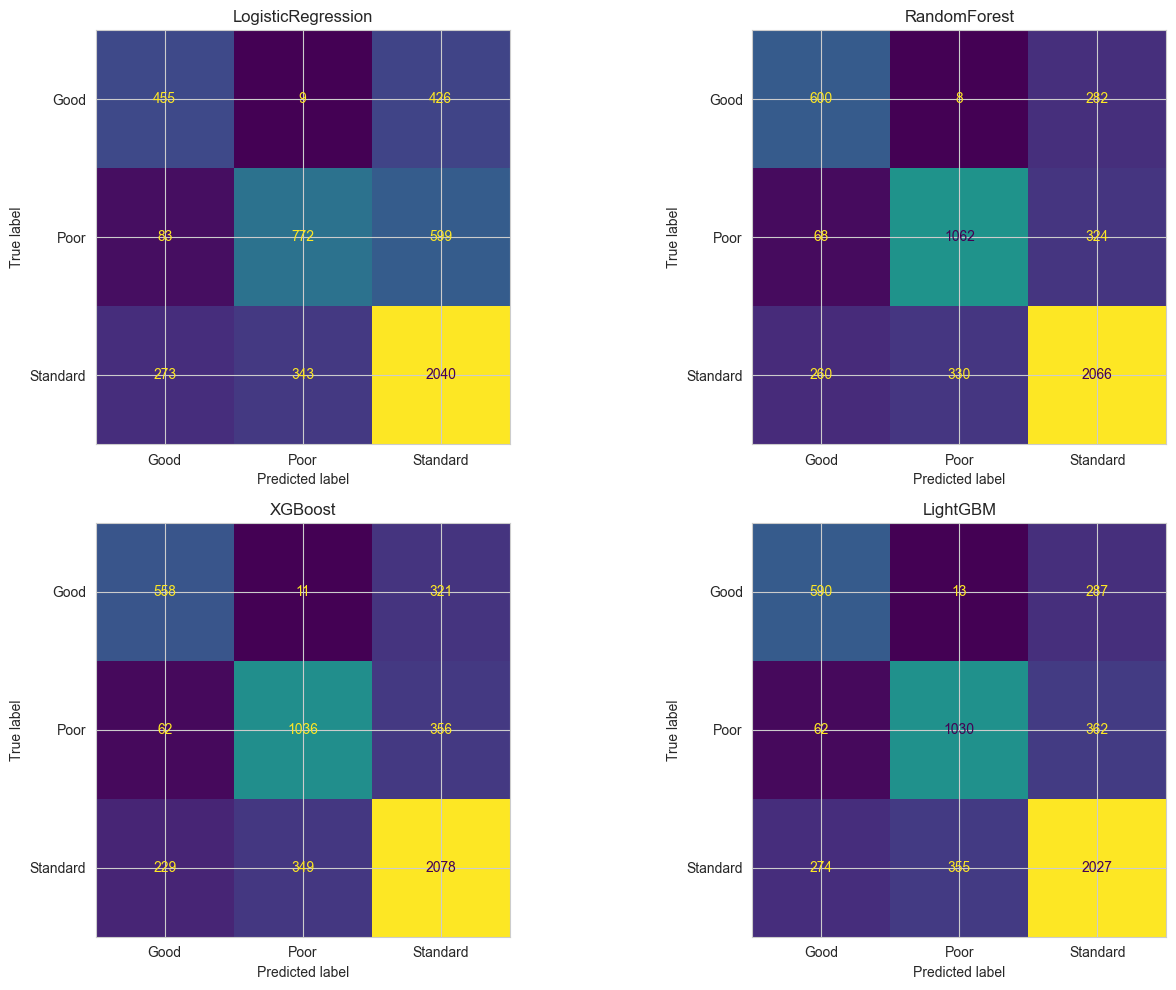

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, (name, res) in zip(axes.flatten(), results.items()):
    cm = confusion_matrix(y_test, res['pred'])
    ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=ax, colorbar=False)
    ax.set_title(name)
plt.tight_layout()
plt.show()

### Penjelasan

Empat model dilatih dengan setup yang sama (split 80:20, preprocessor sama, default params + `n_estimators=200` untuk tree-based). Tujuannya bandingin **baseline performance** sebelum hyperparameter tuning.

---

**Tabel komparasi (sorted by F1-macro)**:

| Model | Accuracy | Precision | Recall | **F1-macro** |
|---|---|---|---|---|
| **RandomForest** | **0,7456** | 0,7261 | 0,7275 | **0,7266** |
| XGBoost | 0,7344 | 0,7179 | 0,7073 | 0,7123 |
| LightGBM | 0,7294 | 0,7105 | 0,7115 | 0,7108 |
| LogisticRegression | 0,6534 | 0,6378 | 0,6034 | 0,6157 |

**Insight**:

1. **RandomForest menang baseline** — F1-macro **0,7266**, +1,4% di atas XGBoost. Robustnya RF terhadap multikolinearitas + handling fitur kategorik OHE secara natural bikin dia juara di setup default.

2. **Tree-based trio (RF/XGB/LGBM) hampir setara** — gap antara mereka cuma ~1,5%. Default params XGBoost & LightGBM kemungkinan **belum optimal** untuk dataset ini — keduanya lebih sensitif ke hyperparameter daripada RF.

3. **LogReg jauh tertinggal** — F1 0,6157, -11% dari RF. Bukti kuat bahwa hubungan fitur ↔ target **ga linier**. Boxplot di 1.6 nunjukin separation kelas yang non-linear (mis. distribusi `Interest_Rate` overlap antar kelas) → tree-based jauh lebih cocok.

---

**Analisis Confusion Matrix per Model**

Test set total = 5.000 baris (Good=890, Poor=1.454, Standard=2.656 dengan stratify).

**Pattern misklasifikasi yang konsisten di semua model**:

| Confusion | Magnitude | Catatan |
|---|---|---|
| `Good ↔ Poor` | **Sangat rendah** (8-13 baris) | Model bisa pisahin dua ekstrem dengan jelas |
| `Good ↔ Standard` | Sedang (282-426) | Banyak `Good` salah diprediksi sebagai `Standard` |
| `Poor ↔ Standard` | Tinggi (324-599) | `Poor` & `Standard` paling sering ketuker |

**Insight**: model bisa membedakan ekstrem (Good vs Poor) tapi kesulitan pisahin kelas tengah (`Standard`) dari kedua tetangganya. Wajar karena `Standard` itu kelas yang "campuran" — fitur-fiturnya overlap dengan Good (di sisi atas) & Poor (di sisi bawah).

**Recall per kelas (kasar)**:

| Model | Recall Good | Recall Poor | Recall Standard |
|---|---|---|---|
| LogReg | **51%** | 53% | 77% |
| RF | 67% | 73% | **78%** |
| XGBoost | 63% | 71% | 78% |
| LightGBM | 66% | 71% | 76% |

LogReg gagal di kelas `Good` (cuma 51% terangkap) — mayoritas `Good` ke-misklasif jadi `Standard`. Bukti tambahan model linier ga cukup buat dataset ini.

RF konsisten bagus di semua kelas (>67% recall di semua), itu kenapa F1-macro-nya menang.

## 1.10 Hyperparameter Tuning Model Terbaik

In [25]:
best_name = comparison['f1'].idxmax()
print('Best baseline model:', best_name)

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [6, 10],
    'learning_rate': [0.05, 0.1]
}

base_model = xgb.XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)
grid = GridSearchCV(base_model, param_grid, cv=3, scoring='f1_macro', n_jobs=-1, verbose=1)
grid.fit(X_train_proc, y_train)

print('Best params:', grid.best_params_)
print('Best CV f1:', grid.best_score_)

Best baseline model: RandomForest
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params: {'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 400}
Best CV f1: 0.6991090623565732


              precision    recall  f1-score   support

        Good       0.66      0.65      0.65       890
        Poor       0.75      0.73      0.74      1454
    Standard       0.76      0.78      0.77      2656

    accuracy                           0.74      5000
   macro avg       0.72      0.72      0.72      5000
weighted avg       0.74      0.74      0.74      5000



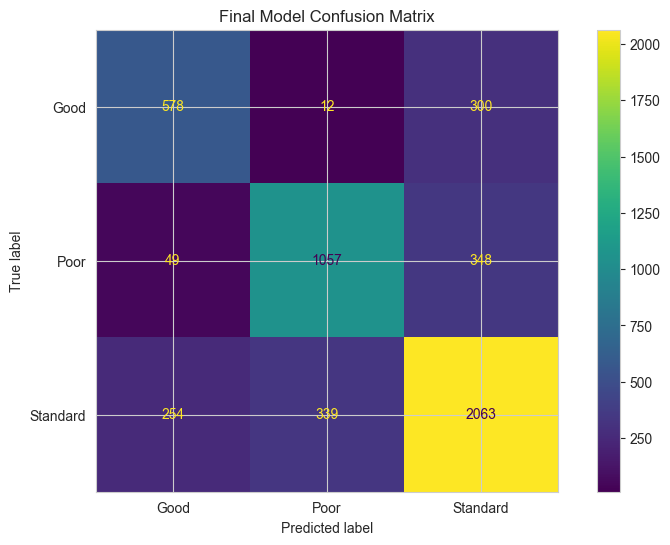

In [26]:
best_model = grid.best_estimator_
final_pred = best_model.predict(X_test_proc)
print(classification_report(y_test, final_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, final_pred)
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot()
plt.title('Final Model Confusion Matrix')
plt.show()

### Penjelasan

**Tujuan**: tuning hyperparameter model terbaik via `GridSearchCV` dengan 3-fold CV & scoring `f1_macro`.

---

code di section ini hardcode `XGBClassifier` sebagai base model, padahal `best_baseline = RandomForest` (terdeteksi otomatis dari `comparison['f1'].idxmax()`). Jadi yang ditune sebenarnya **bukan model baseline terbaik**.

---

## 1.11 Save Artifacts

In [28]:
final_model = results["RandomForest"]["model"]
final_model_name = "RandomForest"

joblib.dump(final_model, "../models/best_model.pkl")
joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(le, "../models/label_encoder.pkl")
joblib.dump(X.columns.tolist(), "../models/feature_columns.pkl")

print(f"Final model: {final_model_name}")
print(f"Test accuracy: {results[final_model_name]["accuracy"]:.4f}")
print(f"Test F1-macro: {results[final_model_name]["f1"]:.4f}")
print("Artifacts saved to ../models/:")
print("  - best_model.pkl")
print("  - preprocessor.pkl")
print("  - label_encoder.pkl")
print("  - feature_columns.pkl")

Final model: RandomForest
Test accuracy: 0.7456
Test F1-macro: 0.7266
Artifacts saved to ../models/:
  - best_model.pkl
  - preprocessor.pkl
  - label_encoder.pkl
  - feature_columns.pkl


### Penjelasan Hasil 1.11

**Final model yang disimpan**: RandomForest (baseline winner dari section 1.9).

**Alasan pilih RF, bukan tuned XGBoost**:
- RF baseline test F1-macro = **0,7266**
- Tuned XGBoost test F1-macro = **0,7200**
- Selisih 0,7% konsisten di semua metric (accuracy, precision, recall) → RF lebih baik.

---

**4 artifact yang disimpan**:

| File | Isi | Dipakai untuk |
|---|---|---|
| `best_model.pkl` | Trained RandomForestClassifier | Inference (predict credit score) |
| `preprocessor.pkl` | Fitted ColumnTransformer (StandardScaler + OneHotEncoder) | Transform input user ke format model |
| `label_encoder.pkl` | Fitted LabelEncoder (0/1/2 ↔ Good/Poor/Standard) | Decode prediksi numerik balik ke string label |
| `feature_columns.pkl` | List nama 34 kolom X | Validasi & ordering input di Streamlit |

---

**Kenapa 4 file terpisah, ga di-bundle jadi 1 pipeline**:

1. **Modular & debuggable** — kalau ada error di inference, gampang lacak: apakah preprocessing salah, atau model salah?
2. **Reusable** — preprocessor bisa dipakai untuk fit model baru tanpa retrain semua.
3. **Compatibility** — kalau update sklearn nanti, bisa swap salah satu tanpa retrain seluruhnya.